# Assignment 3

You only need to write one line of code for each question. When answering questions that ask you to identify or interpret something, the length of your response doesn’t matter. For example, if the answer is just ‘yes,’ ‘no,’ or a number, you can just give that answer without adding anything else.

We will go through comparable code and concepts in the live learning session. If you run into trouble, start by using the help `help()` function in Python, to get information about the datasets and function in question. The internet is also a great resource when coding (though note that **no outside searches are required by the assignment!**). If you do incorporate code from the internet, please cite the source within your code (providing a URL is sufficient).

Please bring questions that you cannot work out on your own to office hours, work periods or share with your peers on Slack. We will work with you through the issue.

### Clustering and Resampling

Let's set up our workspace and use the **Wine dataset** from `scikit-learn`. This dataset is a classic dataset used for clustering tasks. It consists of many samples of wine. Here are the key features and characteristics of the dataset:

##### Features (13 chemical properties):
1. Alcohol: The percentage of alcohol in the wine.
2. Malic acid: A type of acid found in grapes, contributing to wine’s tartness.
3. Ash: The total amount of non-volatile substances left after burning the wine
4. Alcalinity of ash: Measures the alkalinity of the ash component of wine.
5. Magnesium: The amount of magnesium in the wine (measured in mg/L).
6. Total phenols: Represents the total amount of phenolic compounds in wine.
7. Flavanoids: A type of phenolic compound responsible for bitterness and astringency.
8. Nonflavanoid phenols: Phenolic compounds that are not flavonoids.
9. Proanthocyanins: A type of tannin that affects astringency and bitterness.
10. Color intensity: Measures the depth or intensity of the wine’s color. 
11. Hue: The shade of color in the wine (ratio of red to yellow tones).
12. OD280/OD315 of diluted wines: Measures the wine’s absorbance at 280 nm and 315 nm, indicating phenol concentration.
13. Proline: An amino acid found in wine, often associated with aging potential and quality.

In [1]:
# Import standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


#### **Question 1:** 
#### Data inspection

#### Load the Wine dataset:

Use scikit-learn to load the Wine dataset and convert it into a Pandas DataFrame.
Display the first few rows of the dataset. How many observations (rows) and features (columns) does the dataset contain?

In [6]:
from sklearn.datasets import load_wine
# Load the Wine dataset
wine_data = load_wine()

# Convert to DataFrame
wine_df = pd.DataFrame(wine_data.data, columns=wine_data.feature_names)

# Display the DataFrame
# commenting out so that the output for the other print statements will be more clearly visible.
#print(wine_df)

# Your code here...
print("\n \n \n First few roaws of the dataset \n")
print(wine_df.head(5))

print(f"Number of observations(rows): {wine_df.shape[0]} \nNumber of columns(feeatures): {wine_df.shape[1]}")


 
 
 First few roaws of the dataset 

   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_dilut

#### **Question 2:** 
#### Data-visualization

Let's create plots to visualize the relationships between the features (e.g., alcohol, malic acid, ash...).


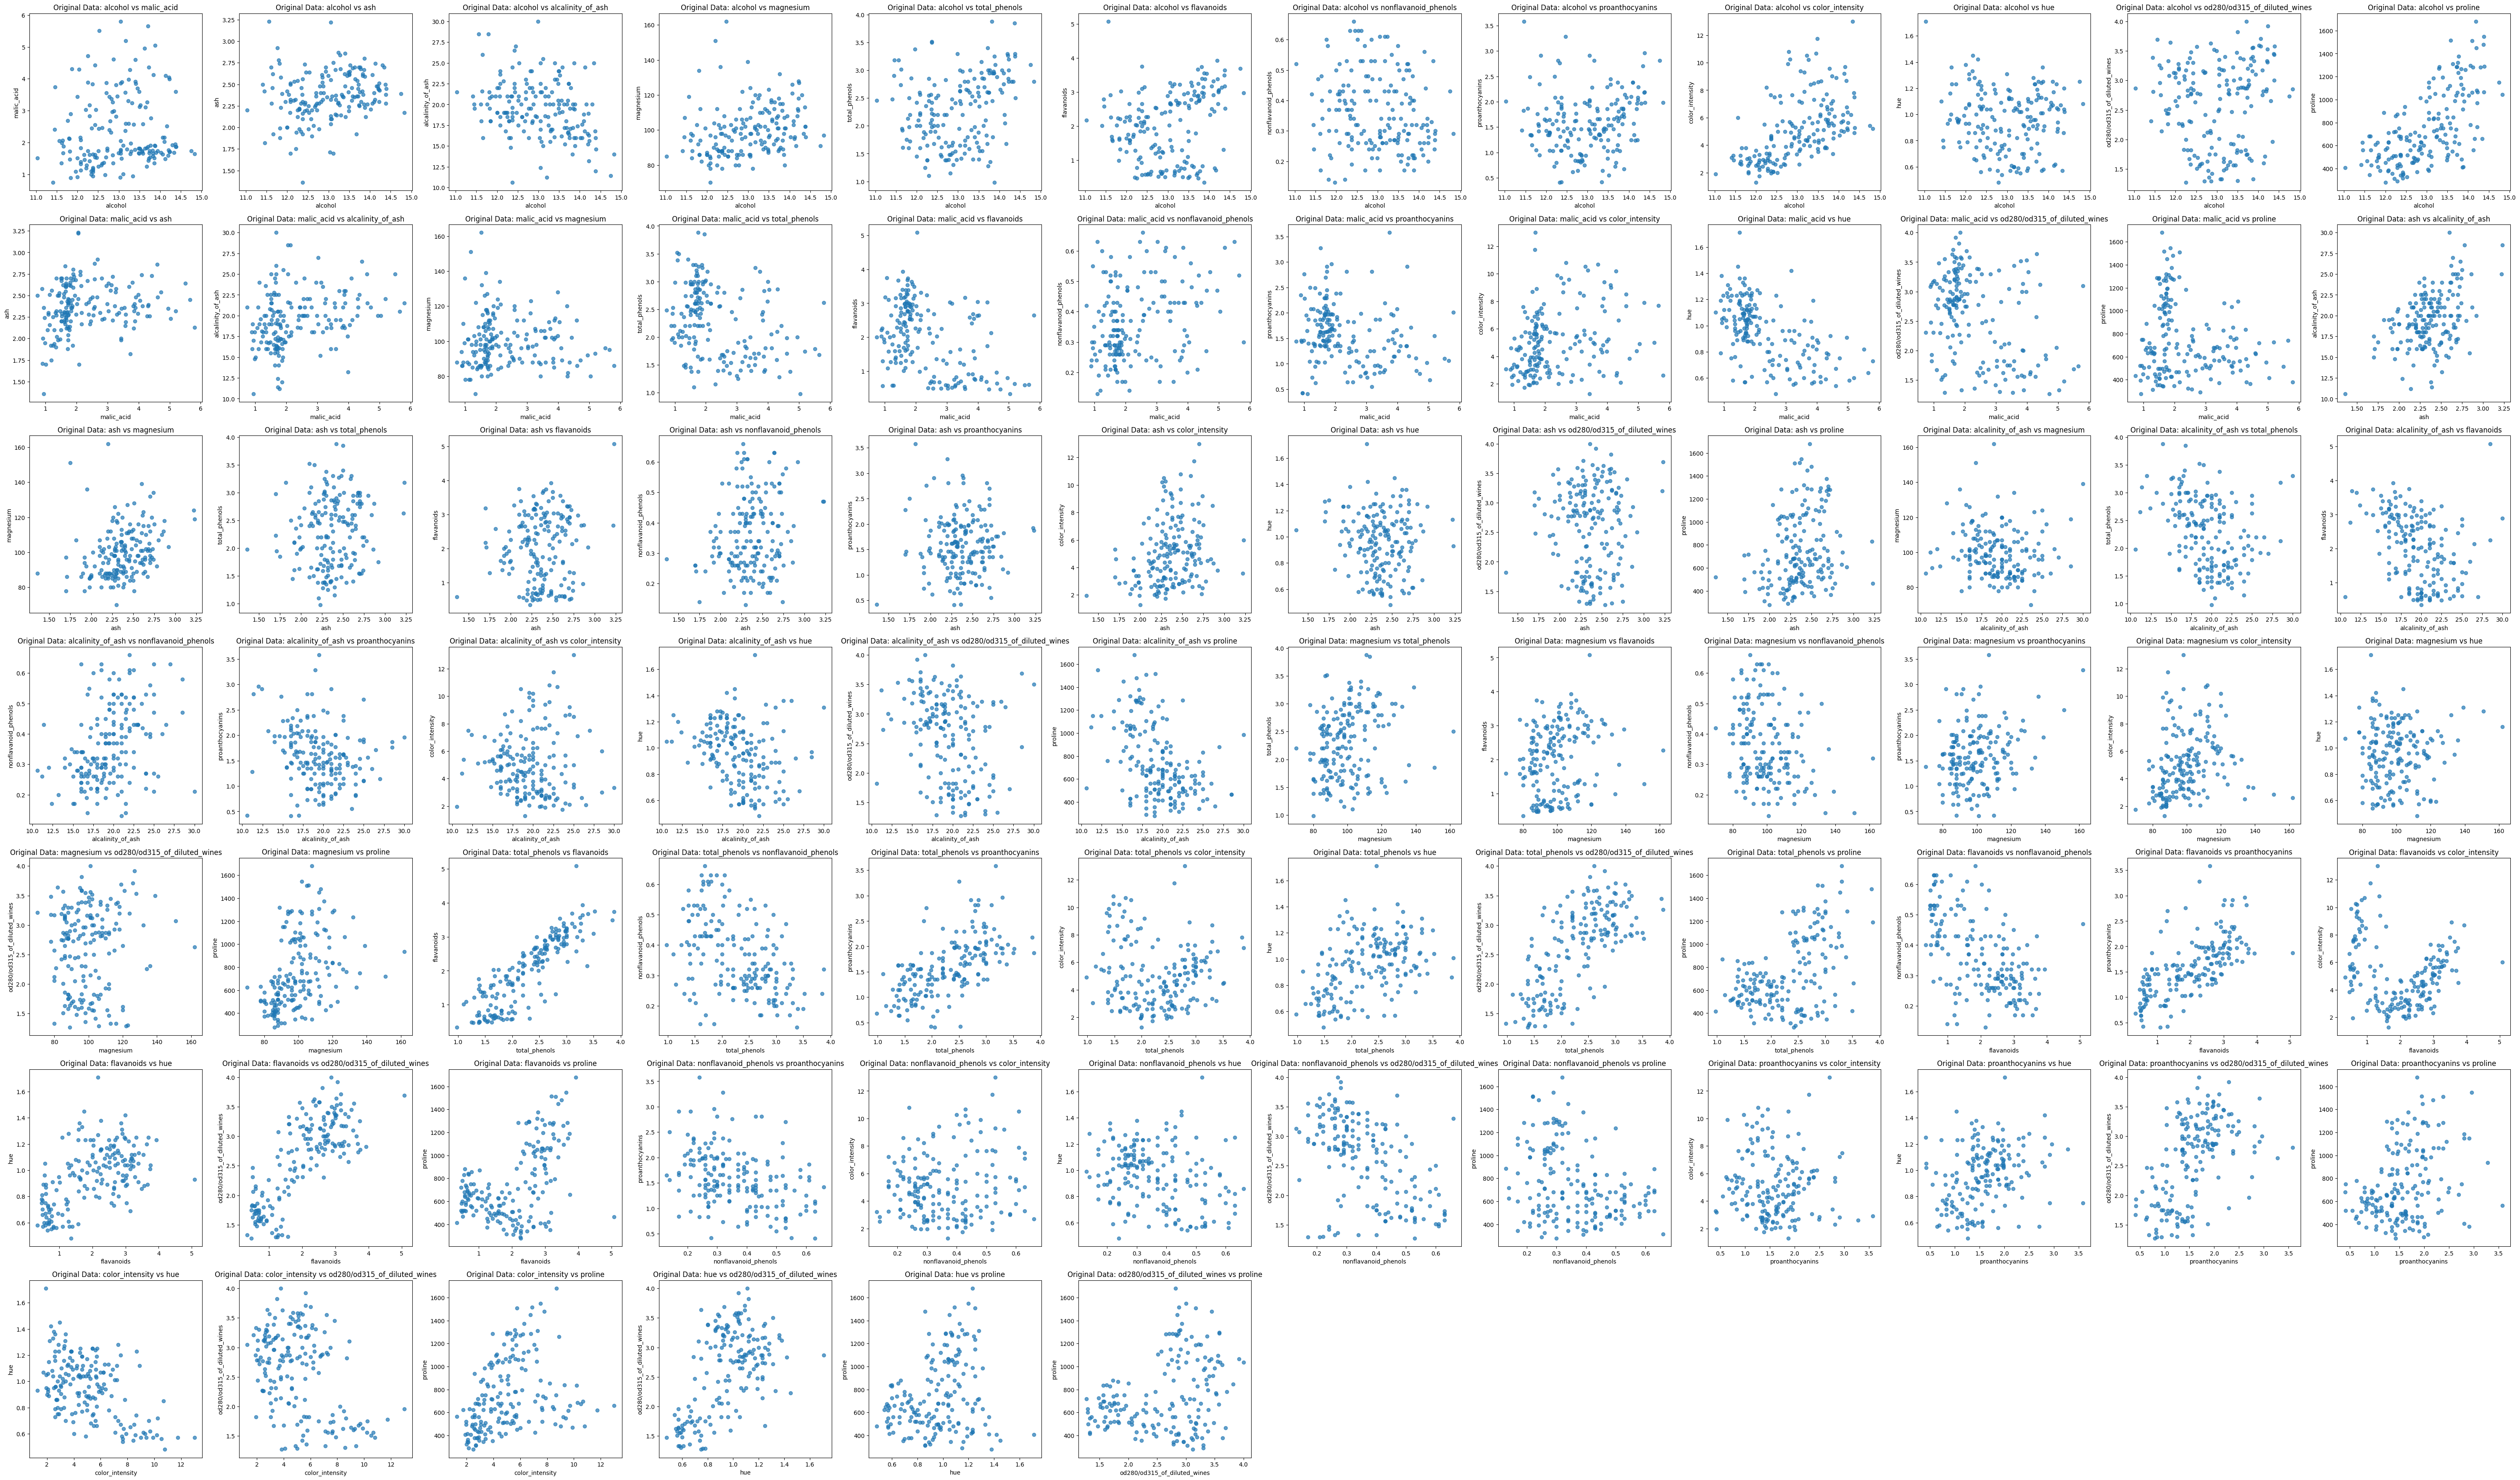

In [3]:
def plot_feature_pairs(data, feature_names, color_labels=None, title_prefix=''):
    """
    Helper function to create scatter plots for all possible pairs of features.
    
    Parameters:
    - data: DataFrame containing the features to be plotted.
    - feature_names: List of feature names to be used in plotting.
    - color_labels: Optional. Cluster or class labels to color the scatter plots.
    - title_prefix: Optional. Prefix for plot titles to distinguish between different sets of plots.
    """
    # Create a figure for the scatter plots
    plt.figure(figsize=(60, 60))
    
    # Counter for subplot index
    plot_number = 1
    
    # Loop through each pair of features
    for i in range(len(feature_names)):
        for j in range(i + 1, len(feature_names)):
            plt.subplot(len(feature_names)-1, len(feature_names)-1, plot_number)
            
            # Scatter plot colored by labels if provided
            if color_labels is not None:
                plt.scatter(data[feature_names[i]], data[feature_names[j]], 
                            c=color_labels, cmap='viridis', alpha=0.7)
            else:
                plt.scatter(data[feature_names[i]], data[feature_names[j]], alpha=0.7)
            
            plt.xlabel(feature_names[i])
            plt.ylabel(feature_names[j])
            plt.title(f'{title_prefix}{feature_names[i]} vs {feature_names[j]}')
            
            # Increment the plot number
            plot_number += 1

    # Adjust layout to prevent overlap
    plt.tight_layout()

    # Show the plot
    plt.show()

# Get feature names
feature_names = wine_df.columns

# Use the helper function to plot scatter plots without coloring by cluster labels
plot_feature_pairs(wine_df, feature_names, title_prefix='Original Data: ')

**Question:**
- Do you notice any patterns or relationships between the different features? How might these patterns help in distinguishing between different species?

> Your answer...
Some plots show positive association between features, for example, 'total_phenols vs flavonoids', 'total_phenols vs proanthocyanins' and 'alcohol vs proline'. Few plots show somewhat of a negative association between features (with a fair bit of outliers), for example, 'color_intensity vs hue'. For some of the plots, the points are scattered, either a bit sparsely or densely in clusters, for example, 'alcohol vs nonflavonoid_phenols' seems to be scattered a bit sparsely and 'hue vs proline' seems to be scaterred a bit more like in two clumps. 

> There are points in different sections of the graphs, for example, eithers in the top right, in the center, etc. The patterns could potentially help us in mapping characteristics to different species of wines. For example, in the 'total_phenols vs hue' plot, the more expensive wines could be the ones with higher total_phenols and higher hues. However, we will likely need to consider more than 2 features to determine how expensive different species of wines are.


#### **Question 3:** 
#### Data cleaning

In [4]:
# Initialize the StandardScaler
scaler = StandardScaler()

# Scale all the features in the dataset
scaled_features = scaler.fit_transform(wine_df)

# Create a new DataFrame with scaled features
scaled_wine_df = pd.DataFrame(scaled_features, columns=wine_data.feature_names)

# Display the first few rows of the scaled DataFrame
print(scaled_wine_df.head())

    alcohol  malic_acid       ash  alcalinity_of_ash  magnesium  \
0  1.518613   -0.562250  0.232053          -1.169593   1.913905   
1  0.246290   -0.499413 -0.827996          -2.490847   0.018145   
2  0.196879    0.021231  1.109334          -0.268738   0.088358   
3  1.691550   -0.346811  0.487926          -0.809251   0.930918   
4  0.295700    0.227694  1.840403           0.451946   1.281985   

   total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
0       0.808997    1.034819             -0.659563         1.224884   
1       0.568648    0.733629             -0.820719        -0.544721   
2       0.808997    1.215533             -0.498407         2.135968   
3       2.491446    1.466525             -0.981875         1.032155   
4       0.808997    0.663351              0.226796         0.401404   

   color_intensity       hue  od280/od315_of_diluted_wines   proline  
0         0.251717  0.362177                      1.847920  1.013009  
1        -0.293321  0.406051

Why is it important to standardize the features of a dataset before applying clustering algorithms like K-Means? Discuss the implications of using unstandardized data in your analysis.

> Your answer here ... 
The answer for this would be similar to that for assignment 1.

> Some predictor variables have values with wider range of values. Consequently, this could result in some variables having potentially more dominance on the distance calculation, as was seen in our in-class lab session with perimeter mean having a stronger influence than concavity mean. In this dataset, some columns have numbers that are of a higher magnitude than some, for example, proline has larger numbers than hue. Standardizing the predictor variables helps to prevent bias by giving all the predictor variables a more equal playing field.

#### **Question 4:** 
#### K-means clustering 

Apply the K-Means clustering algorithm to the Wine dataset. Choose the value 3 for the number of clusters (`k=3`) and fit the model. Assign cluster labels to the original data and add them as a new column in the DataFrame.

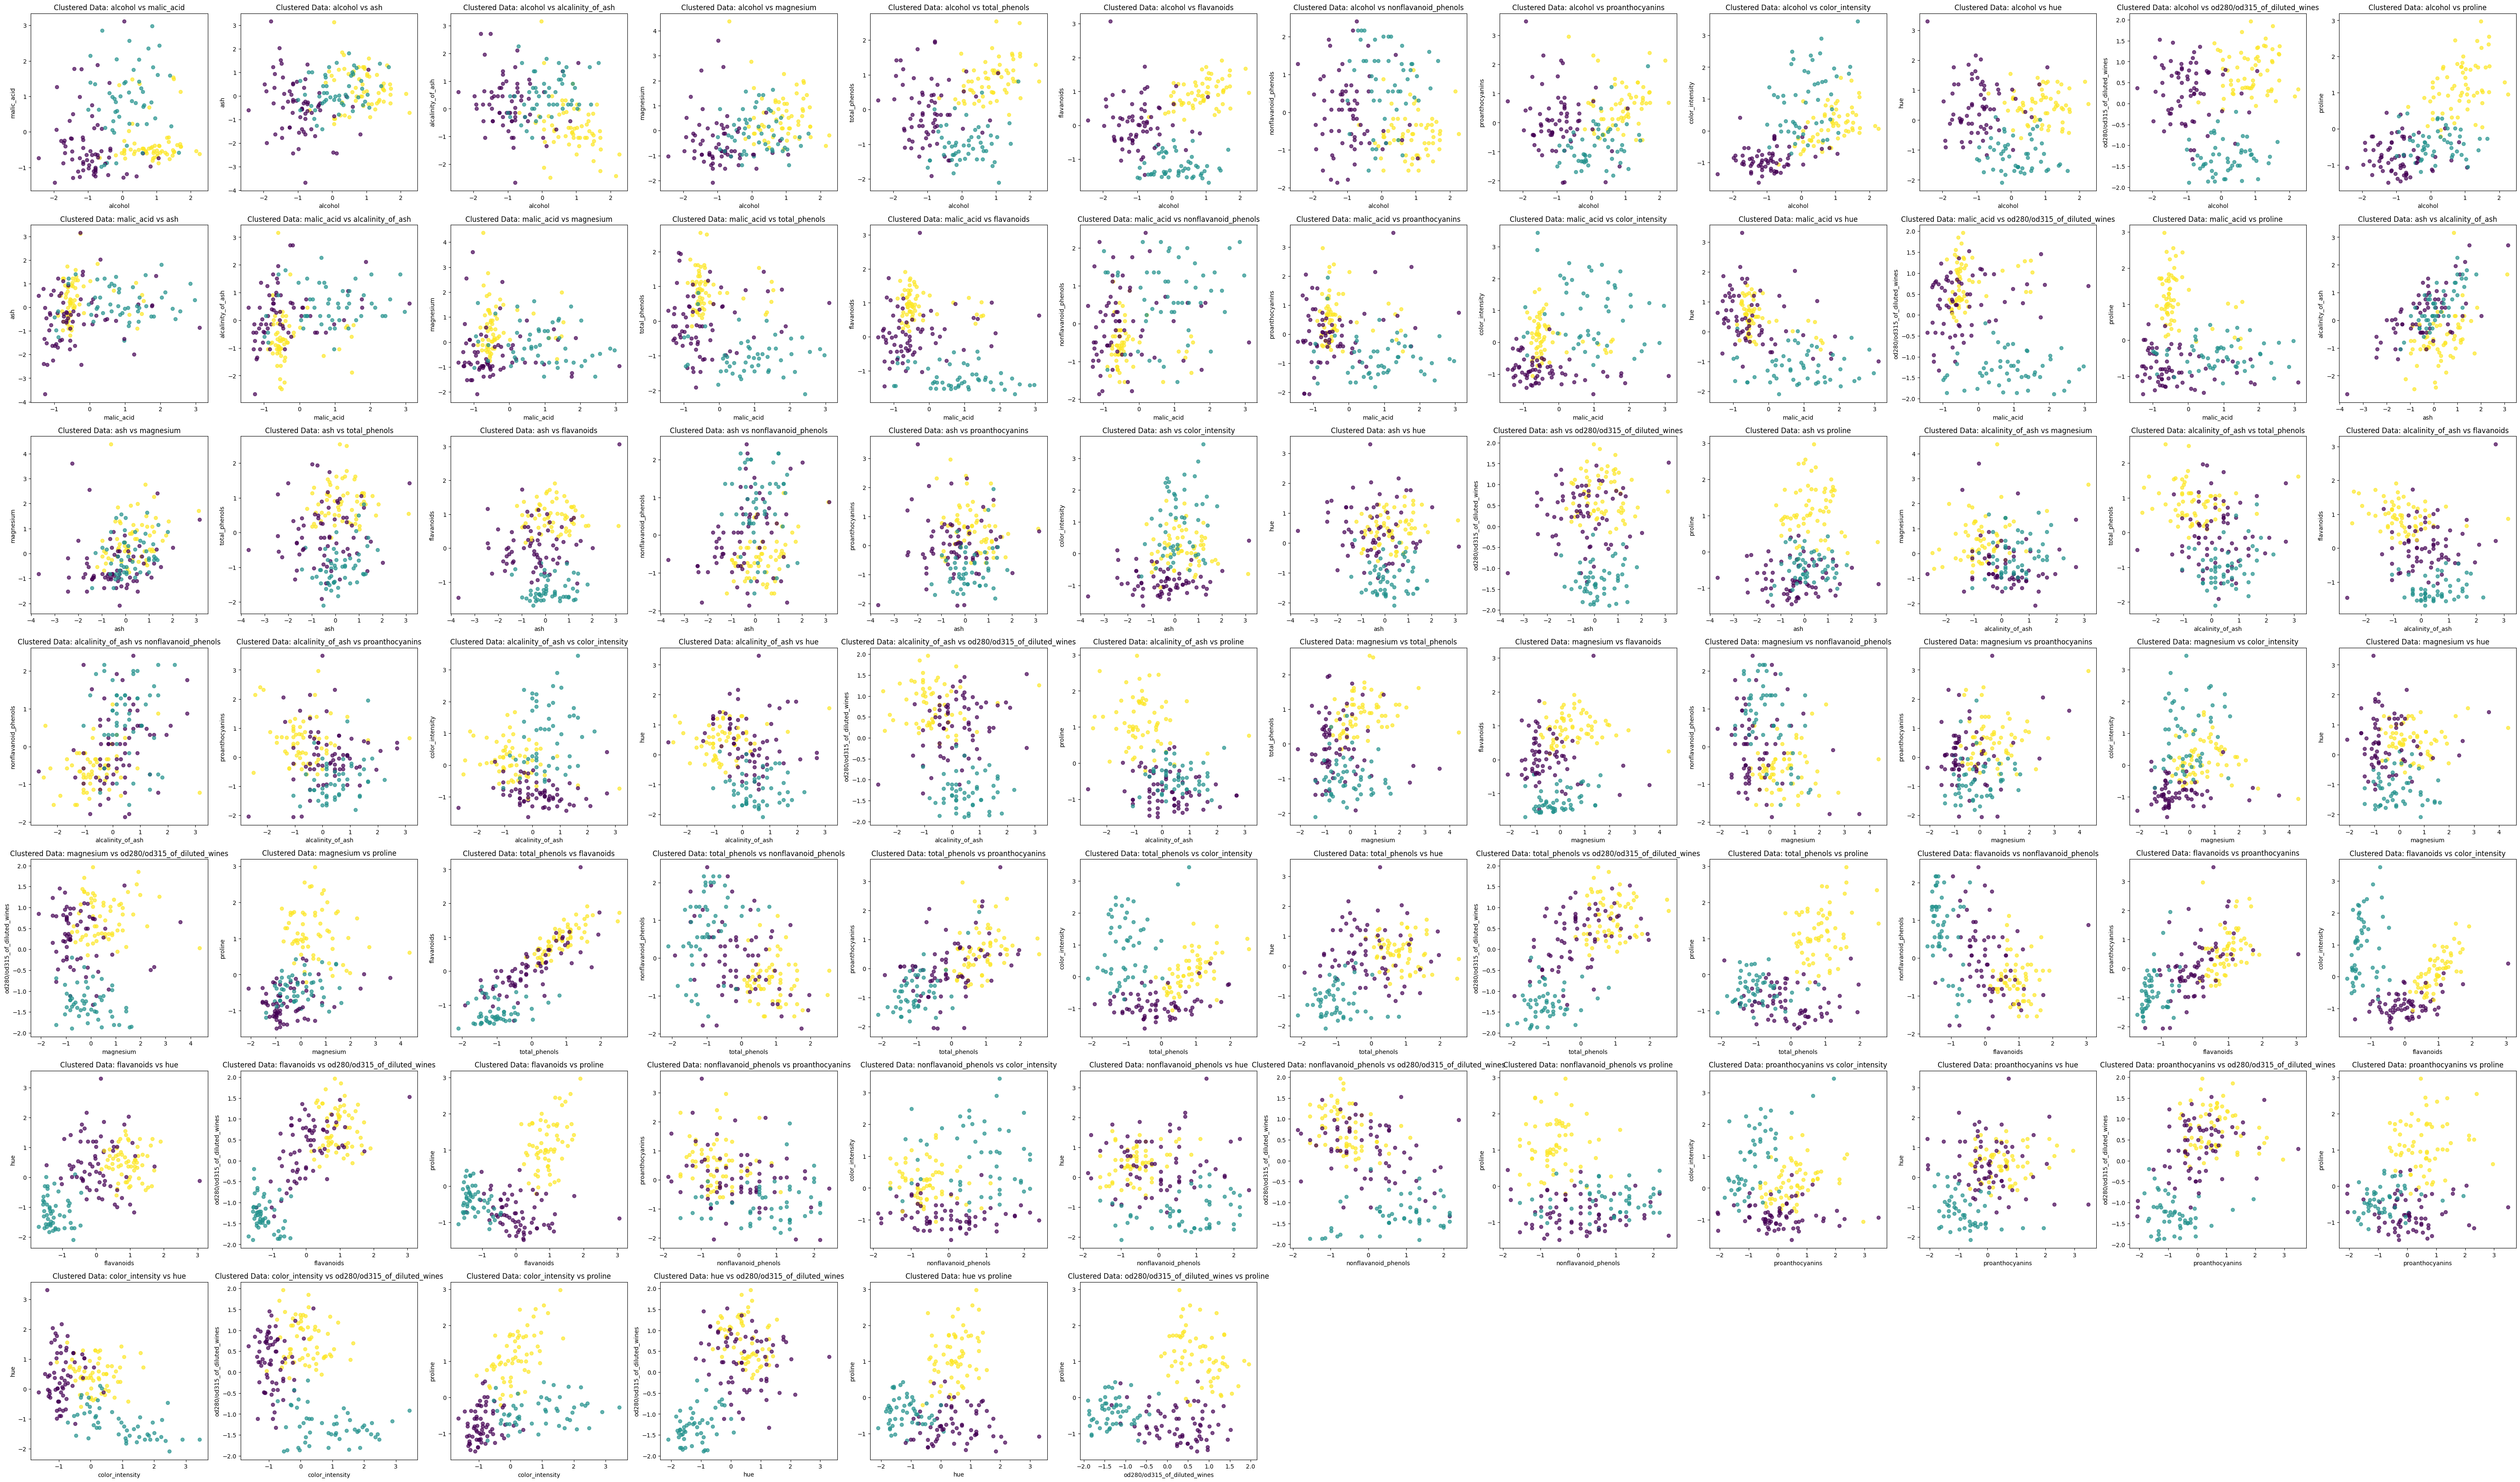

In [9]:
# Your answer...
# Perform K-means clustering
kmeans = KMeans(n_clusters=3, random_state=1)
clusters = kmeans.fit(scaled_wine_df)

clustered_wine_data = scaled_wine_df.copy()
clustered_wine_data['Cluster'] = clusters.labels_



# Use the helper function to plot scatter plots, colored by cluster labels
plot_feature_pairs(clustered_wine_data, feature_names, color_labels=clustered_wine_data['Cluster'], title_prefix='Clustered Data: ')

We chose `k=3` for the number of clusters arbitrarily. However, in a real-world scenario, it is important to determine the optimal number of clusters using appropriate methods.

**Question**: What is one method commonly used to determine the optimal number of clusters in K-means clustering, and why is this method helpful?

> Your answer here...
The inertia gives us an idea how well the number of clusters performed. To determine the optimal number of clusters we could use the elbow method. For this method, we iteratively check the inertia value for different number of k, and keep a note of these values. We then plot the k values on the x-axis and the inertia (Within-Cluster Sum of Squares (WSSD)) on the y-axis. Then we check for the 'elbow' on the plot, the optimal number of clusters - after this point, the decrease in the inertia is no longer so drastic. For further demonstration, I plotted this in the code below. It should also be noted that based on the discussion in our class, it was noted that when relevant, domain knowledge could take preference over the elbow method.

    k         wssd
0   1  2314.000000
1   2  1659.007967
2   3  1279.966153
3   4  1180.271514
4   5  1107.413881
5   6  1046.888596
6   7   991.534140
7   8   948.859494
8   9   934.978221
9  10   893.970343


C:\Users\shafe\AppData\Local\Temp\ipykernel_33788\269572678.py:21: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  wine_clust_ks = pd.concat([wine_clust_ks, current_k], ignore_index=True)


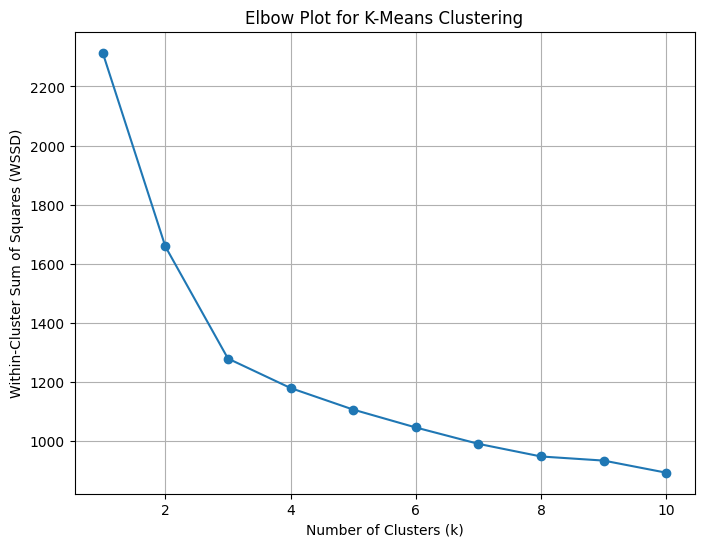

In [11]:
# Adding this code for experimental purpose. From above, it doesn't seem 3 is the ideal number of clusters.
# As confirmed, the inertia is a very high number, which is not ideal.
clusters.inertia_

# Create an empty DataFrame to store the number of clusters (k) 
# and the corresponding within-cluster sum of squared distances (WSSD)
wine_clust_ks = pd.DataFrame(columns=["k", "wssd"])

# Iterate over possible cluster counts from 1 to 10
for k in range(1, 11):
    # Initialize the K-means model with k clusters and a fixed random seed for reproducibility
    kmeans = KMeans(n_clusters=k, random_state=123)
    
    # Fit the model to the scaled wine data
    kmeans.fit(scaled_wine_df)
    
    # Store the current k value and the model's inertia (WSSD) in a temporary DataFrame
    current_k = pd.DataFrame({"k": [k], "wssd": [kmeans.inertia_]})
    
    # Append the results for this k to the cumulative DataFrame
    wine_clust_ks = pd.concat([wine_clust_ks, current_k], ignore_index=True)

# Display the DataFrame
print(wine_clust_ks)

# Create the elbow plot
plt.figure(figsize=(8, 6))
plt.plot(wine_clust_ks['k'], wine_clust_ks['wssd'], marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Within-Cluster Sum of Squares (WSSD)')
plt.title('Elbow Plot for K-Means Clustering')
plt.grid(True)
plt.show()

#### **Question 5:** 
#### Bootstrapping 

Implement bootstrapping on the mean of `color intensity`. Generate 10000 bootstrap samples, calculate the mean for each sample, and compute a 90% confidence interval.

Mean of Color Intensity: 5.058089882022472
90% Confidence Interval of Mean Color Intensity: (4.778817409550562, 5.345019657303371)

 Plotting the graph for the bootstrap distribution for further illustration.


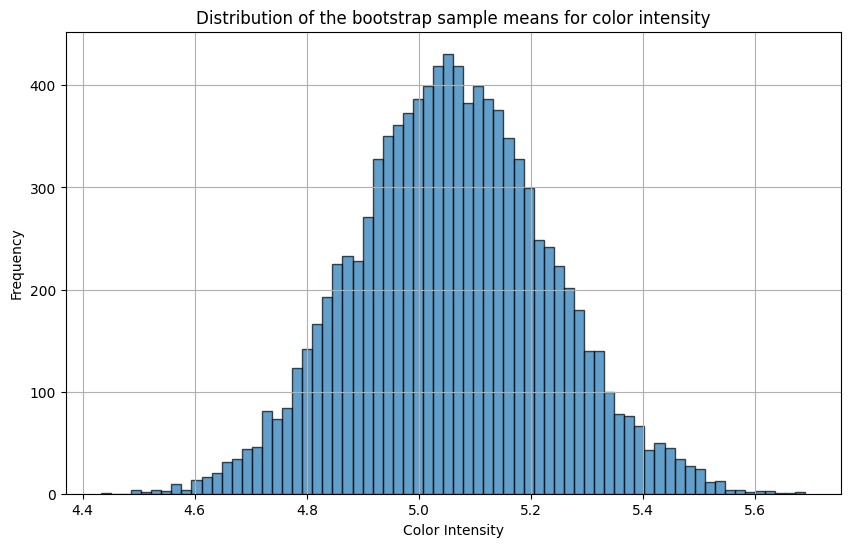

In [21]:
# Your answer here...

mean_color_intensity = wine_df['color_intensity'].mean()

np.random.seed(123)

# Initialize an empty list to store the bootstrap samples
bootstrap_samples = []

for i in range(10_000):
    sample = wine_df.sample(frac=1, replace=True)  # Sample with replacement
    sample = sample.assign(replicate=i)  # Add replicate number
    bootstrap_samples.append(sample)  # Store the sample

# Combine all bootstrap samples into one DataFrame
boot10000 = pd.concat(bootstrap_samples)

# Display the combined DataFrame
#boot10000

# Calculate the mean color intensity for each bootstrap sample (replicate)
boot_means = boot10000.groupby('replicate')['color_intensity'].mean().reset_index(name='mean_color_intensity')

ci_bounds = boot_means["mean_color_intensity"].quantile([0.05, 0.95])
ci_bounds

lower_bound = ci_bounds[0.05]
upper_bound = ci_bounds[0.95]

# Display the result
print(f"Mean of Color Intensity: {mean_color_intensity}")
print(f"90% Confidence Interval of Mean Color Intensity: ({lower_bound}, {upper_bound})")

# Plot the histogram of the bootstrap distribution
print("\n Plotting the graph for the bootstrap distribution for further illustration.")
plt.figure(figsize=(10, 6))
plt.hist(boot_means['mean_color_intensity'], bins=70, edgecolor='black', alpha=0.7)

# Add titles and labels
plt.title('Distribution of the bootstrap sample means for color intensity')
plt.xlabel('Color Intensity')
plt.ylabel('Frequency')

# Show the plot
plt.grid(True)
plt.show()

**Question:**
- Why do we use bootstrapping in this context? What does it help us understand about the mean?

>  Your answer...
We use bootstrapping to get the confidence interval for the true mean from the sample dataset. It helps us determine how accurate our mean for the color intensity is. 

> By applying the bootstrap method to the wine dataset, we can simulate many new samples from our original data and get a better sense of how much the average color intensity might vary.

**Question:**
- What is the purpose of calculating the confidence interval from the bootstrap samples? How does it help us interpret the variability of the estimate?

> Your answer...
The confidence interval likely contain the true population parameter (color_intensity mean). The narrower the interval, the better. If we took many samples that is reflective of the population, the true value will likely fall within that range.

**Question:**

- Reflect on the variability observed in the bootstrapped means and discuss whether the mean of the color intensity appears to be a stable and reliable estimate based on the confidence interval and the spread of the bootstrapped means.

> Your answer here...
The confidence interval is between ~ 4.778 and ~ 5.345, and the mean of the color intensity is ~5.058. The plot is a bell shape and almost symmetrical. The average for the interval is ~5.0615 which is very close to the mean, and the bootstrap distribution is centered on the color intensity mean. Therefore, I would say the mean of the color intensity appears to be a stable and reliable estimate based on the confidence interval and spread of the bootstrap means. If we look at the bell curve, the peak is very close to the mean, and the mean is indeed within the confidence interval.

# Criteria


| **Criteria**                                           | **Complete**                                      | **Incomplete**                                    |
|--------------------------------------------------------|---------------------------------------------------|--------------------------------------------------|
| **Data Inspection**                                    | Data is thoroughly inspected for the number of variables, observations, and data types, and relevant insights are noted. | Data inspection is missing or lacks detail.         |
| **Data Visualization**                                 | Visualizations (e.g., scatter plots) are correctly interpreted to explore relationships between features and species. | Visualizations are not correctly interpreted. |
| **Clustering Implementation**                           | K-Means clustering is correctly implemented, and cluster labels are appropriately assigned to the dataset.            | K-Means clustering is missing or incorrectly implemented. |
| **Bootstrapping Process**                              | Bootstrapping is correctly performed, and results are used to assess variable mean stability. | Bootstrapping is missing or incorrectly performed. |

## Submission Information

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.

### Note:

If you like, you may collaborate with others in the cohort. If you choose to do so, please indicate with whom you have worked with in your pull request by tagging their GitHub username. Separate submissions are required.

### Submission Parameters:
* Submission Due Date: `11:59 PM - 12/10/2025`
* The branch name for your repo should be: `assignment-3`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_3.ipynb) should be populated and should be the only change in your pull request.
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/LCR/pull/<pr_id>`
    * Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.

Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.

If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#dc2-help`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.
